In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [119]:
df = pd.read_csv('Customer-Churn-Records.csv')
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0,0,1,DIAMOND,300
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,0,5,PLATINUM,771
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1,1,3,SILVER,564
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,1,2,GOLD,339


In [120]:
df.isna().sum()

RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64

In [121]:
df['Exited'].value_counts()

Exited
0    7962
1    2038
Name: count, dtype: int64

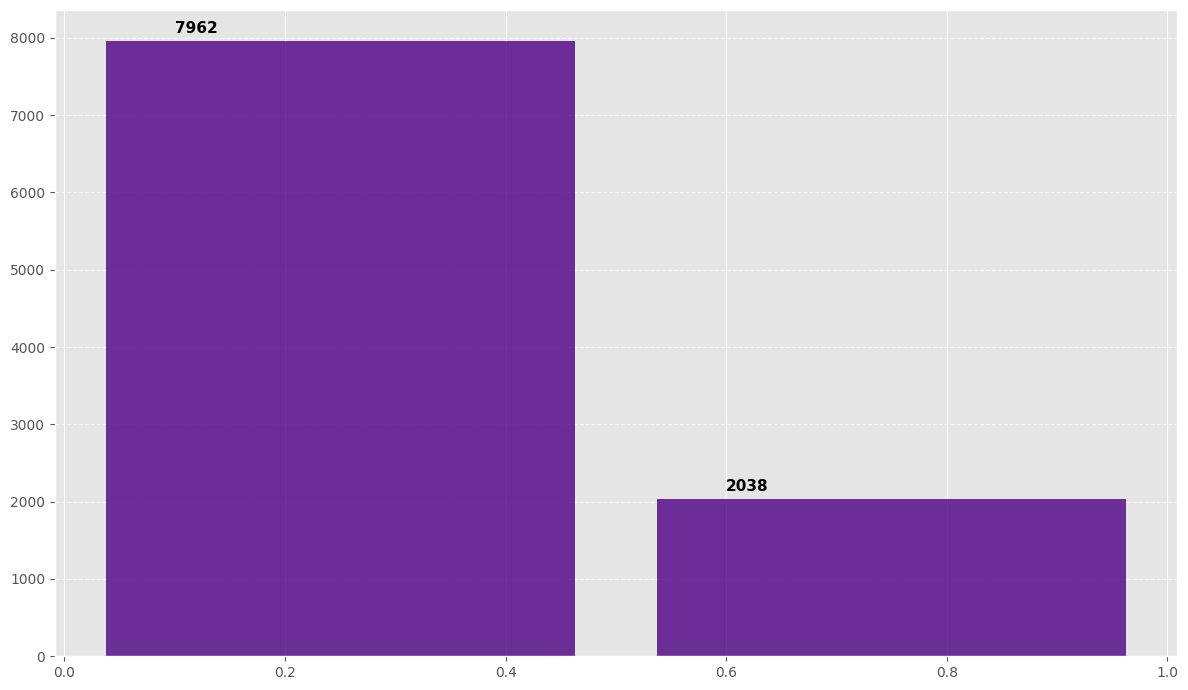

In [122]:
plt.style.use('ggplot')  # Use ggplot style for better aesthetics
plt.figure(figsize=(12, 7))

# Create histogram with improved styling
plt.hist(df['Exited'], bins=2, color='#4B0082', alpha=0.8, rwidth=0.85)

# Customize the plot
plt.title('Distribution of Customer Churn', fontsize=16, pad=20)
plt.xlabel('Churn Status (0 = Stayed, 1 = Churned)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

# Add value labels on top of each bar
counts, bins, _ = plt.hist(df['Exited'], bins=2)
plt.clf()  # Clear the figure
plt.hist(df['Exited'], bins=2, color='#4B0082', alpha=0.8, rwidth=0.85)
for count, x in zip(counts, bins):
    plt.text(x + 0.1, count + 100, f'{int(count)}', 
             fontweight='bold', fontsize=11)

# Add grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tight layout to prevent label cutoff
plt.tight_layout()

# Show the plot
plt.show()

<Axes: xlabel='Exited'>

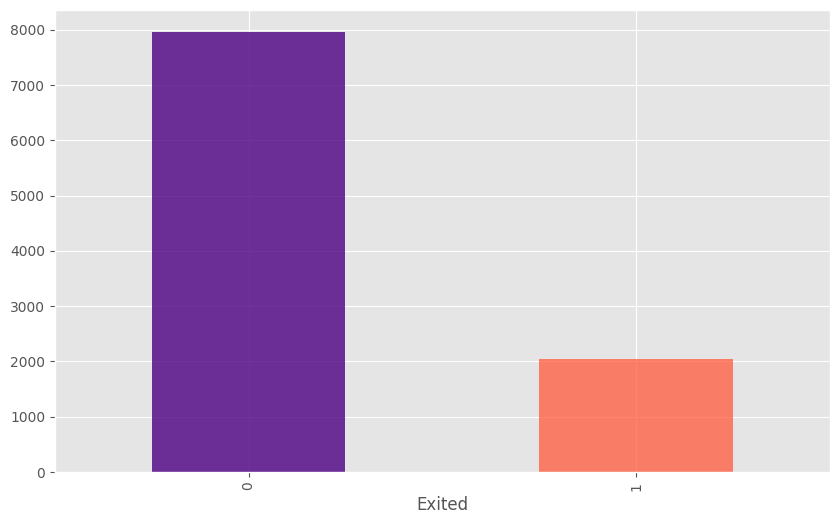

In [144]:
df["Exited"].value_counts().plot(kind='bar', color=['#4B0082', '#FF6347'], figsize=(10, 6), alpha=0.8)

In [123]:
for col in df.columns:
    if df[col].dtype == 'object':
        print(f"{col}: {df[col].unique()}")
    else:
        print(f"{col}: {df[col].describe()}")    

RowNumber: count    10000.00000
mean      5000.50000
std       2886.89568
min          1.00000
25%       2500.75000
50%       5000.50000
75%       7500.25000
max      10000.00000
Name: RowNumber, dtype: float64
CustomerId: count    1.000000e+04
mean     1.569094e+07
std      7.193619e+04
min      1.556570e+07
25%      1.562853e+07
50%      1.569074e+07
75%      1.575323e+07
max      1.581569e+07
Name: CustomerId, dtype: float64
Surname: ['Hargrave' 'Hill' 'Onio' ... 'Kashiwagi' 'Aldridge' 'Burbidge']
CreditScore: count    10000.000000
mean       650.528800
std         96.653299
min        350.000000
25%        584.000000
50%        652.000000
75%        718.000000
max        850.000000
Name: CreditScore, dtype: float64
Geography: ['France' 'Spain' 'Germany']
Gender: ['Female' 'Male']
Age: count    10000.000000
mean        38.921800
std         10.487806
min         18.000000
25%         32.000000
50%         37.000000
75%         44.000000
max         92.000000
Name: Age, dtype: float6

In [124]:
df.drop(['CustomerId', 'RowNumber', 'Surname'], axis=1, inplace=True)
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0,0,1,DIAMOND,300
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,0,5,PLATINUM,771
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1,1,3,SILVER,564
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,1,2,GOLD,339


In [125]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [126]:
df['Card Type'].value_counts()

Card Type
DIAMOND     2507
GOLD        2502
SILVER      2496
PLATINUM    2495
Name: count, dtype: int64

In [127]:
df['Gender'] = df['Gender'].apply(lambda x: 1 if x == 'Male' else 0)

In [128]:
from sklearn.preprocessing import OneHotEncoder
def encode(df, columns_to_encode):
    encoder = OneHotEncoder(sparse_output=False, drop='first')
    encoded_data = encoder.fit_transform(df[columns_to_encode])
    cols = encoder.get_feature_names_out(columns_to_encode)
    encoded_df = pd.DataFrame(encoded_data, columns=cols, index=df.index)
    df = pd.concat([df.drop(columns_to_encode, axis=1), encoded_df], axis=1)
    return df


In [129]:
columns_to_encode = ['Geography', 'Card Type']
df = encode(df, columns_to_encode)

In [130]:
df

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned,Geography_Germany,Geography_Spain,Card Type_GOLD,Card Type_PLATINUM,Card Type_SILVER
0,619,0,42,2,0.00,1,1,1,101348.88,1,1,2,464,0.0,0.0,0.0,0.0,0.0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,1,3,456,0.0,1.0,0.0,0.0,0.0
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1,3,377,0.0,0.0,0.0,0.0,0.0
3,699,0,39,1,0.00,2,0,0,93826.63,0,0,5,350,0.0,0.0,1.0,0.0,0.0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,5,425,0.0,1.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,1,39,5,0.00,2,1,0,96270.64,0,0,1,300,0.0,0.0,0.0,0.0,0.0
9996,516,1,35,10,57369.61,1,1,1,101699.77,0,0,5,771,0.0,0.0,0.0,1.0,0.0
9997,709,0,36,7,0.00,1,0,1,42085.58,1,1,3,564,0.0,0.0,0.0,0.0,1.0
9998,772,1,42,3,75075.31,2,1,0,92888.52,1,1,2,339,1.0,0.0,1.0,0.0,0.0


In [132]:
X = df.drop(['Exited', 'Complain'], axis=1)
y = df['Exited']

In [133]:
# Add feature interactions and transformations
X['Balance_per_Product'] = X['Balance'] / (X['NumOfProducts'] + 1)
X['Tenure_Score'] = X['Tenure'] * X['CreditScore']

In [134]:
X

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Satisfaction Score,Point Earned,Geography_Germany,Geography_Spain,Card Type_GOLD,Card Type_PLATINUM,Card Type_SILVER,Balance_per_Product,Tenure_Score
0,619,0,42,2,0.00,1,1,1,101348.88,2,464,0.0,0.0,0.0,0.0,0.0,0.000000,1238
1,608,0,41,1,83807.86,1,0,1,112542.58,3,456,0.0,1.0,0.0,0.0,0.0,41903.930000,608
2,502,0,42,8,159660.80,3,1,0,113931.57,3,377,0.0,0.0,0.0,0.0,0.0,39915.200000,4016
3,699,0,39,1,0.00,2,0,0,93826.63,5,350,0.0,0.0,1.0,0.0,0.0,0.000000,699
4,850,0,43,2,125510.82,1,1,1,79084.10,5,425,0.0,1.0,1.0,0.0,0.0,62755.410000,1700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,1,39,5,0.00,2,1,0,96270.64,1,300,0.0,0.0,0.0,0.0,0.0,0.000000,3855
9996,516,1,35,10,57369.61,1,1,1,101699.77,5,771,0.0,0.0,0.0,1.0,0.0,28684.805000,5160
9997,709,0,36,7,0.00,1,0,1,42085.58,3,564,0.0,0.0,0.0,0.0,1.0,0.000000,4963
9998,772,1,42,3,75075.31,2,1,0,92888.52,2,339,1.0,0.0,1.0,0.0,0.0,25025.103333,2316


In [135]:
y

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Exited, Length: 10000, dtype: int64

In [136]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True, stratify=y)

In [137]:
len(X_train)

8000

## Random Forest Classifier


In [138]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [139]:
y_pred = rf.predict(X_test)

In [140]:
rf.score(X_test, y_test)

0.861

In [141]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1592
           1       0.78      0.44      0.56       408

    accuracy                           0.86      2000
   macro avg       0.83      0.70      0.74      2000
weighted avg       0.85      0.86      0.85      2000



In [142]:
feature_importances = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

print(feature_importances)

                feature  importance
2                   Age    0.209439
5         NumOfProducts    0.115157
8       EstimatedSalary    0.082882
16  Balance_per_Product    0.080319
10         Point Earned    0.079036
4               Balance    0.078159
0           CreditScore    0.077726
17         Tenure_Score    0.072781
3                Tenure    0.039669
7        IsActiveMember    0.031547
9    Satisfaction Score    0.030981
11    Geography_Germany    0.029520
1                Gender    0.016467
6             HasCrCard    0.012294
12      Geography_Spain    0.011116
13       Card Type_GOLD    0.011110
14   Card Type_PLATINUM    0.010994
15     Card Type_SILVER    0.010804


In [143]:
# 3. Check correlation matrix for features
correlation_matrix = X.corr()
print("High correlations:")
print(correlation_matrix[abs(correlation_matrix) > 0.8])

High correlations:
                     CreditScore  Gender  Age    Tenure  Balance  \
CreditScore                  1.0     NaN  NaN       NaN      NaN   
Gender                       NaN     1.0  NaN       NaN      NaN   
Age                          NaN     NaN  1.0       NaN      NaN   
Tenure                       NaN     NaN  NaN  1.000000      NaN   
Balance                      NaN     NaN  NaN       NaN  1.00000   
NumOfProducts                NaN     NaN  NaN       NaN      NaN   
HasCrCard                    NaN     NaN  NaN       NaN      NaN   
IsActiveMember               NaN     NaN  NaN       NaN      NaN   
EstimatedSalary              NaN     NaN  NaN       NaN      NaN   
Satisfaction Score           NaN     NaN  NaN       NaN      NaN   
Point Earned                 NaN     NaN  NaN       NaN      NaN   
Geography_Germany            NaN     NaN  NaN       NaN      NaN   
Geography_Spain              NaN     NaN  NaN       NaN      NaN   
Card Type_GOLD               